In [ ]:
import seaborn as sns

penguins = sns.load_dataset("penguins")
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Task 1

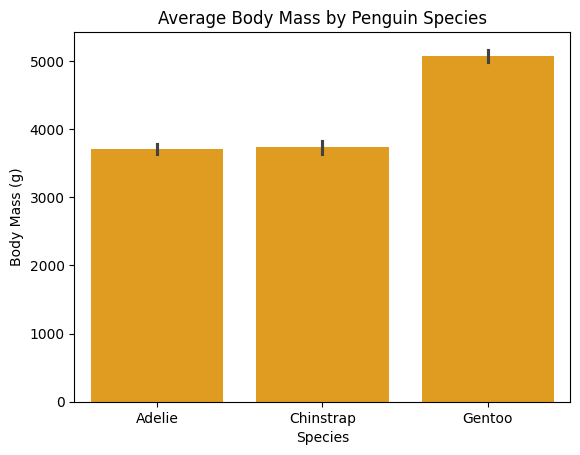

In [ ]:
from numpy import mean
import matplotlib.pyplot as plt

sns.barplot(data=penguins, x="species", y="body_mass_g", estimator=mean, color="orange")

plt.title("Average Body Mass by Penguin Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")

plt.show()


# Task 2

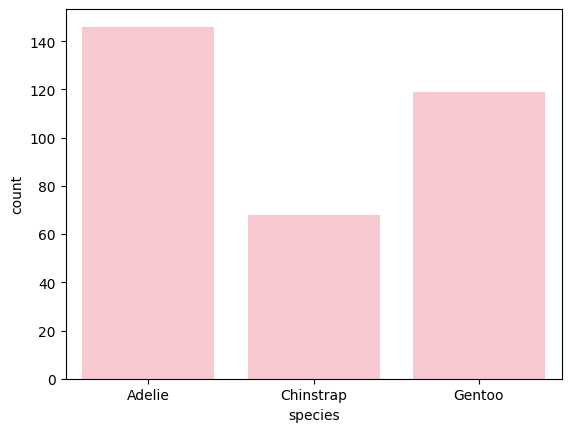

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=penguins, x = "species", color="pink")

plt.show()

#The species Adelie is most common


# Task 3

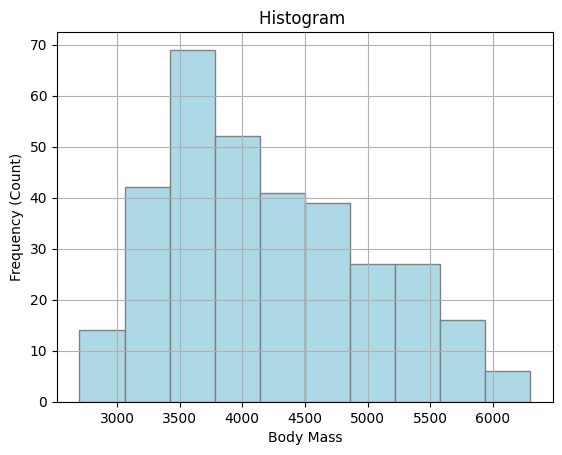

In [ ]:
penguins.hist(column="body_mass_g", edgecolor="grey", color="lightblue")

plt.xlabel('Body Mass')
plt.ylabel('Frequency (Count)')
plt.title('Histogram ')

plt.show()

#Right-skewed because the graph's tail stretches to the right. It shows most values of body mass are low, except a few high outlier values which pull the avergae upward


# Task 4

Text(0.5, 1.0, 'Boxplot')

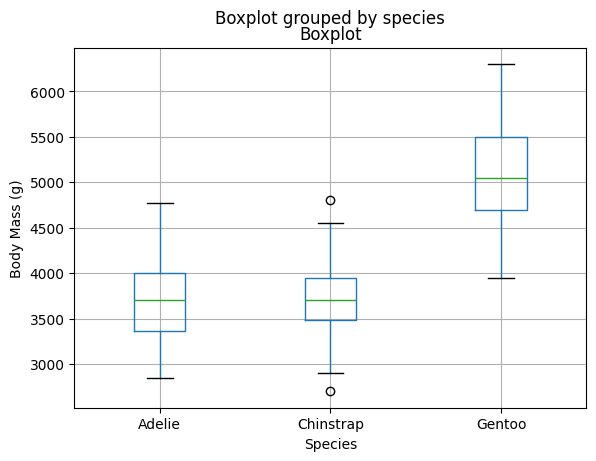

In [ ]:
penguins.boxplot(column="body_mass_g", by="species")

plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.title("Boxplot")

#there are two outliers visible in the boxplot

# Task 5

In [ ]:
Q1 = penguins["body_mass_g"].quantile(0.25)
Q3 = penguins["body_mass_g"].quantile(0.75)
iqr = Q3 - Q1
lower = Q1 - 1.5*iqr
upper = Q3 + 1.5*iqr

outliers = penguins[(penguins["body_mass_g"] < lower) | (penguins["body_mass_g"] > upper)]
print(len(outliers))


#the outliers calculated here and the outliers displayed in the box plot above do not match. This is because the above task is visualised with respect to categories, whereas the manual calculation assumes the whole dataset

0


# Task 6

In [ ]:
from scipy import stats
penguins['zscore'] = stats.zscore(penguins['body_mass_g'])
outliers_z = penguins

outliers_z = penguins[penguins['zscore'].abs() > 3]
print(len(outliers_z))

#iqr and z-score flag the same number of outliers, which in this case is 0.

0


# Task 7

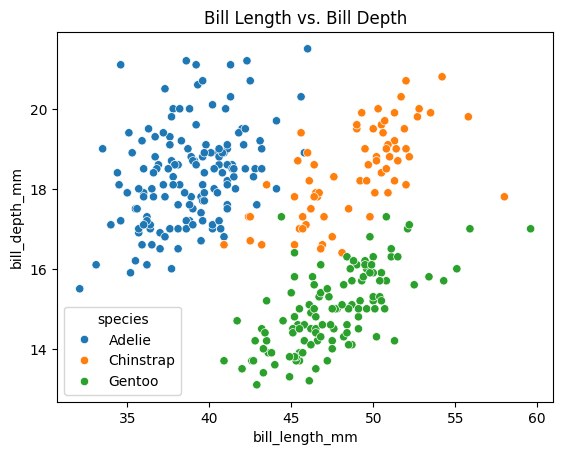

In [ ]:
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', hue ="species")

plt.title("Bill Length vs. Bill Depth")
plt.show()


#there is no meaningful relationship between Bill Length and Bill Depth since the points are scattered randomly and form no clear pattern

# Task 8

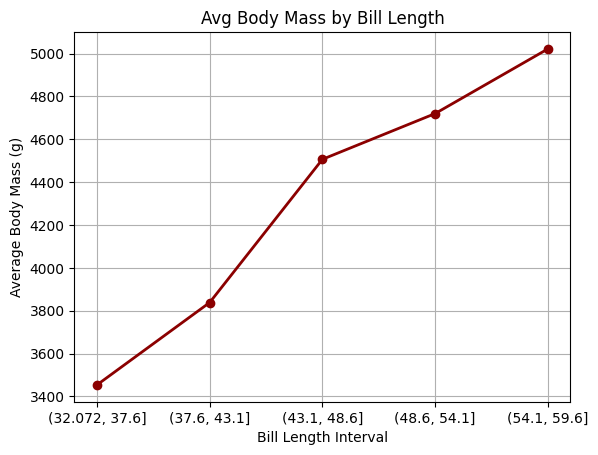

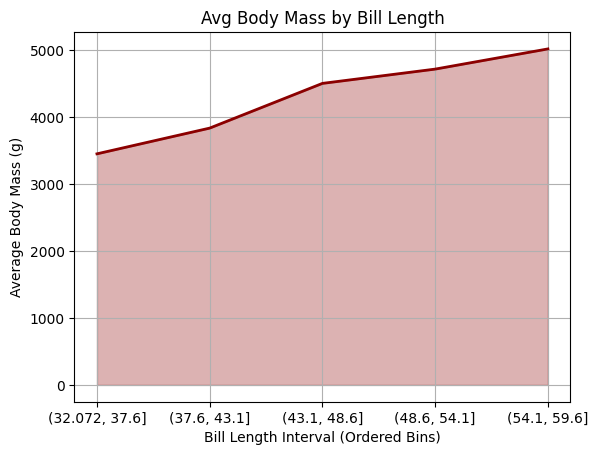

In [ ]:
import pandas as pd


penguins = sns.load_dataset("penguins").dropna()
penguins["bill_length_bin"] = pd.cut(penguins["bill_length_mm"], bins=5)

df_grouped = penguins.groupby("bill_length_bin", observed=False)["body_mass_g"].mean()
x_labels = [str(interval) for interval in df_grouped.index]


plt.plot(x_labels, df_grouped.values, marker="o", color="darkred", linewidth=2)

plt.title("Avg Body Mass by Bill Length")
plt.xlabel("Bill Length Interval")
plt.ylabel("Average Body Mass (g)")
plt.grid(True)
plt.show()


plt.plot(x_labels, df_grouped.values, color="darkred", linewidth=2)
plt.fill_between(x_labels, df_grouped.values, color="darkred", alpha=0.3)

plt.title("Avg Body Mass by Bill Length")
plt.xlabel("Bill Length Interval (Ordered Bins)")
plt.ylabel("Average Body Mass (g)")
plt.grid(True)
plt.show()


#an area graph turns a line graph into a solid shape, showing volume and magnitude instead of just a trend

# Task 9

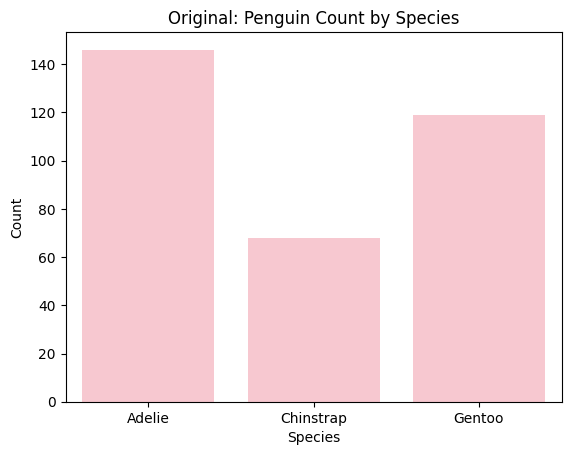

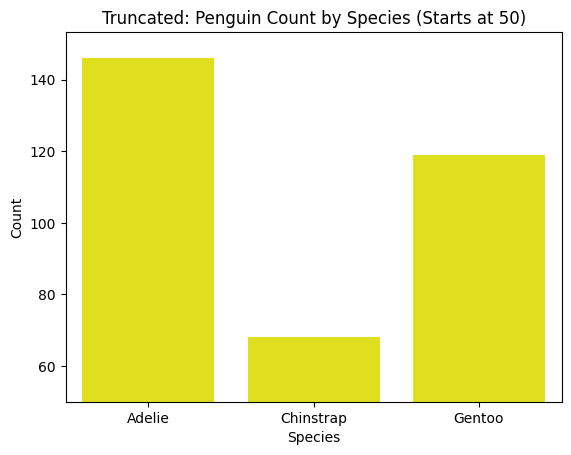

In [ ]:
sns.countplot(data=penguins, x="species", color="pink")

plt.title("Original: Penguin Count by Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

sns.countplot(data=penguins, x="species", color="yellow")

plt.ylim(bottom=50)

plt.title("Truncated: Penguin Count by Species (Starts at 50)")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

#The original graph shows the differences in penguin counts accurately from zero, making the species sizes look more proportional. The truncated graph starts the y-axis at 50, which makes the differences between species appear much larger than they actually are. Even though the data values have not changed, the truncated axis can make the differences seem more dramatic.

